In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

C:\Users\USER\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\USER\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv(r"C:\Users\USER\Downloads\ML TASK\googleplaystore.csv")

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [4]:
df.shape

(10841, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [6]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [8]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


# DATA CLEANING

In [9]:
df["Reviews"].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'], dtype=object)

In [10]:
df['Reviews'].str.isnumeric().sum()

10840

In [11]:
df[~df['Reviews'].str.isnumeric()] # ~----> not

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [12]:
df_copy = df.copy()

In [13]:
df_copy = df_copy.drop(df_copy.index[10472])

In [14]:
df_copy.head(3)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [15]:
df_copy[~df_copy['Reviews'].str.isnumeric()] # ~----> not

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [16]:
df_copy['Reviews'] = df_copy['Reviews'].astype(int)

In [17]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int32  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int32(1), object(11)
memory usage: 1.1+ MB


In [18]:
df_copy.size

140920

In [19]:
df_copy['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [20]:
df_copy['Size'] = df_copy['Size'].str.replace('M', '000').str.replace('k', '').str.replace('Varies with device','nan')

In [21]:
df_copy['Size'].unique()

array(['19000', '14000', '8.7000', '25000', '2.8000', '5.6000', '29000',
       '33000', '3.1000', '28000', '12000', '20000', '21000', '37000',
       '2.7000', '5.5000', '17000', '39000', '31000', '4.2000', '7.0000',
       '23000', '6.0000', '6.1000', '4.6000', '9.2000', '5.2000', '11000',
       '24000', 'nan', '9.4000', '15000', '10000', '1.2000', '26000',
       '8.0000', '7.9000', '56000', '57000', '35000', '54000', '201',
       '3.6000', '5.7000', '8.6000', '2.4000', '27000', '2.5000', '16000',
       '3.4000', '8.9000', '3.9000', '2.9000', '38000', '32000', '5.4000',
       '18000', '1.1000', '2.2000', '4.5000', '9.8000', '52000', '9.0000',
       '6.7000', '30000', '2.6000', '7.1000', '3.7000', '22000', '7.4000',
       '6.4000', '3.2000', '8.2000', '9.9000', '4.9000', '9.5000',
       '5.0000', '5.9000', '13000', '73000', '6.8000', '3.5000', '4.0000',
       '2.3000', '7.2000', '2.1000', '42000', '7.3000', '9.1000', '55000',
       '23', '6.5000', '1.5000', '7.5000', '51000'

In [22]:
df_copy['Size'] = df_copy['Size'].astype(float)

In [23]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int32  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int32(1), object(10)
memory usage: 1.1+ MB


In [24]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [25]:
df_copy['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [26]:
df_copy['Installs'] = df_copy['Installs'].str.replace('+','').str.replace(',','')

In [27]:
df_copy["Installs"].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [28]:
df_copy["Installs"] = df_copy["Installs"].astype(int)

In [29]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int32  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int32  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int32(2), object(9)
memory usage: 1.1+ MB


In [30]:
df_copy['Type']

0        Free
1        Free
2        Free
3        Free
4        Free
         ... 
10836    Free
10837    Free
10838    Free
10839    Free
10840    Free
Name: Type, Length: 10840, dtype: object

In [31]:
df_copy["Type"].value_counts()

Type
Free    10039
Paid      800
Name: count, dtype: int64

In [32]:
df_copy['Price'].unique()

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [33]:
df_copy["Price"] = df_copy["Price"].str.replace('$','',regex=False)
df_copy["Price"] = pd.to_numeric(df_copy["Price"],errors='coerce')

In [34]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int32  
 4   Size            9145 non-null   float64
 5   Installs        10840 non-null  int32  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(3), int32(2), object(8)
memory usage: 1.1+ MB


In [35]:
df_copy["Content Rating"].unique()

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [36]:
df_copy["Genres"].unique()

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [37]:
df_cleaned = df_copy.dropna()

In [38]:
df_cleaned.shape

(7723, 13)

Average rating should be between 1 and 5 as only these values are allowed on the play store. Drop the rows that have a value outside this range.

In [39]:
df_cleaned = df_cleaned[(df_cleaned['Rating'] >= 1.0) & (df_cleaned['Rating'] <= 5.0)]

In [40]:
df_cleaned.shape

(7723, 13)

In [41]:
df_cleaned = df_cleaned[df_cleaned['Reviews'] <= df_cleaned['Installs']]

In [42]:
df_cleaned.shape

(7717, 13)

For free apps (type = “Free”), the price should not be >0. Drop any such rows.

In [43]:
df_cleaned = df_cleaned[(df_cleaned['Type'] != 'Free') | (df_cleaned['Price'] <= 0)]

In [44]:
df_cleaned.shape

(7717, 13)

In [45]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7717 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             7717 non-null   object 
 1   Category        7717 non-null   object 
 2   Rating          7717 non-null   float64
 3   Reviews         7717 non-null   int32  
 4   Size            7717 non-null   float64
 5   Installs        7717 non-null   int32  
 6   Type            7717 non-null   object 
 7   Price           7717 non-null   float64
 8   Content Rating  7717 non-null   object 
 9   Genres          7717 non-null   object 
 10  Last Updated    7717 non-null   object 
 11  Current Ver     7717 non-null   object 
 12  Android Ver     7717 non-null   object 
dtypes: float64(3), int32(2), object(8)
memory usage: 783.8+ KB


In [46]:
df_cleaned.describe()

,Rating,Reviews,Size,Installs,Price
count,7717.000000,7.717000e+03,7717.000000,7.717000e+03,7717.000000
mean,4.173293,2.951275e+05,21110.437761,8.430620e+06,1.128725
std,0.544362,1.864640e+06,24919.701371,5.017636e+07,17.414784
min,1.000000,1.000000e+00,1.000000,5.000000e+00,0.000000
25%,4.000000,1.090000e+02,6.100000,1.000000e+04,0.000000
50%,4.300000,2.351000e+03,14000.000000,1.000000e+05,0.000000
75%,4.500000,3.910900e+04,33000.000000,1.000000e+06,0.000000
max,5.000000,4.489389e+07,100000.000000,1.000000e+09,400.000000


In [47]:
df_cleaned['Price'].unique()

array([  0.  ,   4.99,   6.99,   7.99,   3.99,   5.99,   2.99,   1.99,
         9.99,   0.99,   9.  ,   5.49,  10.  ,  24.99,  11.99,  79.99,
        16.99,  14.99,  29.99,  12.99,   3.49,  10.99,   7.49,   1.5 ,
        19.99,  15.99,  33.99,  39.99,   2.49,   4.49,   1.7 ,   1.49,
         3.88, 399.99,  17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,
         1.61,   1.59,   6.49,   1.29, 299.99, 379.99,  37.99,  18.99,
       389.99,   8.49,   1.75,  14.  ,   2.  ,   3.08,   2.59,  19.4 ,
        15.46,   8.99,   3.04,  13.99,   4.29,   3.28,   4.6 ,   1.  ,
         2.9 ,   1.97,   2.56,   1.2 ])

In [48]:
df_cleaned[df_cleaned.duplicated('App')].shape

(700, 13)

In [49]:
df_cleaned = df_cleaned.drop_duplicates(subset=['App'],keep='first') #inplace=True

In [50]:
df_cleaned.shape

(7017, 13)

In [51]:
df_cleaned = df_cleaned.drop(['Last Updated','Current Ver','Android Ver'], axis=1)

In [52]:
df_cleaned.shape

(7017, 10)

# EDA

In [53]:
numerical_feature = [feature for feature in df_cleaned.columns if df_cleaned[feature].dtype!='O' ]
categorical_feature = [feature for feature in df_cleaned.columns if df_cleaned[feature].dtype =='O' ]

In [54]:
print(numerical_feature)

['Rating', 'Reviews', 'Size', 'Installs', 'Price']


In [55]:
print(categorical_feature)

['App', 'Category', 'Type', 'Content Rating', 'Genres']


## Univariate analysis

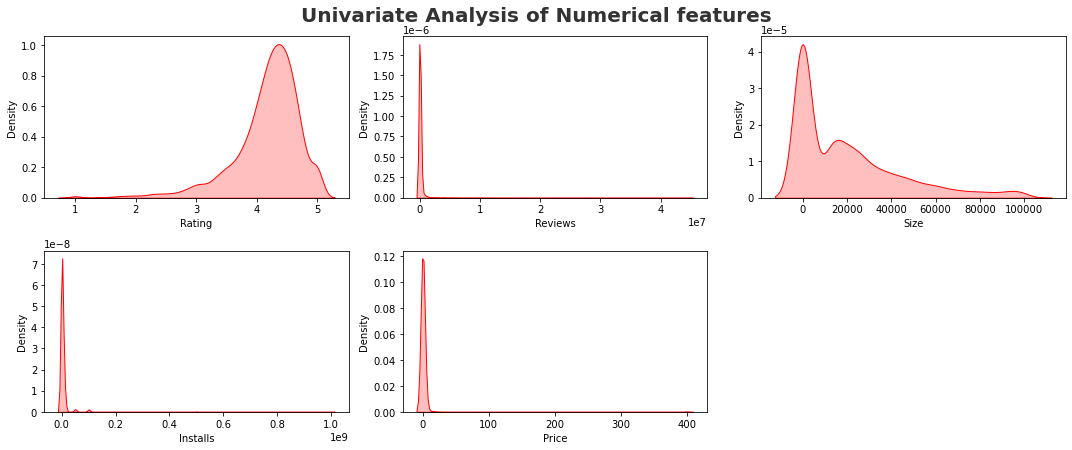

In [56]:
plt.figure(figsize=(15,15))
plt.suptitle('Univariate Analysis of Numerical features',fontsize=20,fontweight='bold',alpha=0.8)

for i in range(0,len(numerical_feature)):
    plt.subplot(5,3,i+1)
    sns.kdeplot(x=df_cleaned[numerical_feature[i]],shade=True,color='r')
    plt.xlabel(numerical_feature[i])
    plt.tight_layout()

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

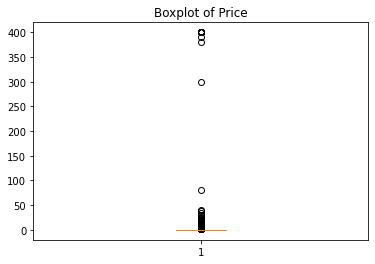

In [58]:
plt.boxplot(df_cleaned['Price'])
plt.title('Boxplot of Price')
plt.show()

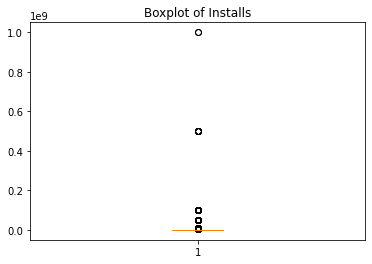

In [59]:
plt.boxplot(df_cleaned['Installs'])
plt.title('Boxplot of Installs')
plt.show()

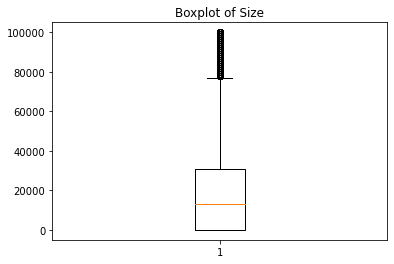

In [60]:
plt.boxplot(df_cleaned['Size'])
plt.title('Boxplot of Size')
plt.show()

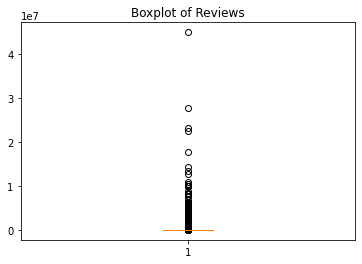

In [61]:
plt.boxplot(df_cleaned['Reviews'])
plt.title('Boxplot of Reviews')
plt.show()

Observation:

Outliers are present in these columns :
    
    1.Price
    2.Installs
    3.Size
    4.Reviews

## Outlier treatment: 

In [62]:
df_cleaned['Price'].value_counts()

Price
0.00      6480
0.99       101
2.99        97
4.99        61
1.99        53
          ... 
6.49         1
1.29         1
299.99       1
7.49         1
1.20         1
Name: count, Length: 68, dtype: int64

In [63]:
df_cleaned = df_cleaned[df_cleaned['Price'] <200]

In [64]:
df_cleaned = df_cleaned[df_cleaned['Reviews']<=2_00_000]

In [65]:
df_cleaned.shape

(6381, 10)

In [66]:
df_cleaned['Installs'].max()

100000000

In [67]:
df_cleaned = df_cleaned[df_cleaned['Installs']<=10_000_000]

In [68]:
df_cleaned.shape

(6371, 10)

## Bivariate analysis: 

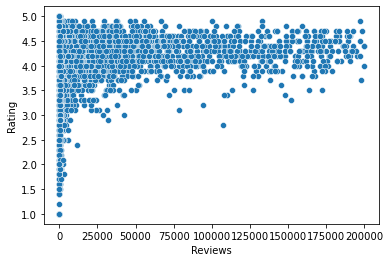

In [69]:
sns.scatterplot(data=df_cleaned, x='Reviews', y='Rating')
plt.show()

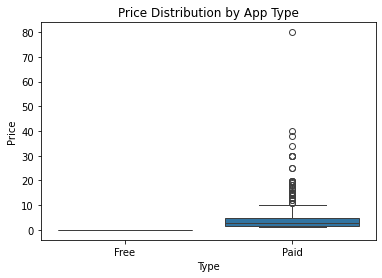

In [70]:
sns.boxplot(data=df_cleaned, x='Type', y='Price')
plt.title("Price Distribution by App Type")
plt.show()


# Data preprocessing


Reviews and Install have some values that are still relatively very high. Before building a linear regression model, you need to reduce the skew. Apply log transformation (np.log1p) to Reviews and Installs.R

In [71]:
df_cleaned = df_cleaned.drop(['App'],axis=1)

In [72]:
X = df_cleaned.drop(columns=['Rating'])

y = df_cleaned['Rating']

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(4778, 8) (4778,)
(1593, 8) (1593,)


In [74]:
X_train.dtypes

Category           object
Reviews             int32
Size              float64
Installs            int32
Type               object
Price             float64
Content Rating     object
Genres             object
dtype: object

In [75]:
X_train_cat = X_train.select_dtypes(include=['object'])
X_train_num = X_train.select_dtypes(include=['int64', 'float64','int32'])

In [76]:
X_train_cat.head()

,Category,Type,Content Rating,Genres
8546,COMMUNICATION,Free,Everyone,Communication
1620,LIFESTYLE,Free,Everyone,Lifestyle
6535,LIBRARIES_AND_DEMO,Free,Everyone,Libraries & Demo
44,ART_AND_DESIGN,Free,Everyone,Art & Design
220,BUSINESS,Free,Everyone,Business


In [77]:
X_train_num.head()

,Reviews,Size,Installs,Price
8546,25,2.9,5000,0.0
1620,78298,29000.0,5000000,0.0
6535,66,728.0,10000,0.0
44,26,12000.0,10000,0.0
220,74359,25000.0,1000000,0.0


In [78]:
X_train_num["Reviews"] = np.log1p(X_train_num["Reviews"])

In [79]:
X_train_num["Size"] = np.log1p(X_train_num["Size"])

In [80]:
X_train_num["Installs"] = np.log1p(X_train_num["Installs"])

In [81]:
X_train_num["Price"] = np.log1p(X_train_num["Price"])

In [82]:
X_train_num.head()

,Reviews,Size,Installs,Price
8546,3.258097,1.360977,8.517393,0.0
1620,11.268290,10.275086,15.424949,0.0
6535,4.204693,6.591674,9.210440,0.0
44,3.295837,9.392745,9.210440,0.0
220,11.216673,10.126671,13.815512,0.0


In [83]:
# OneHotEncoding the categorical features
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(
                               handle_unknown="ignore")

In [84]:
X_train_cat.head(2)

,Category,Type,Content Rating,Genres
8546,COMMUNICATION,Free,Everyone,Communication
1620,LIFESTYLE,Free,Everyone,Lifestyle


In [85]:
# One-hot encoder setup
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)  # Set sparse=False for dense output

# Fit-transform and convert to DataFrame
X_train_cat_transformed = pd.DataFrame(
    onehot_encoder.fit_transform(X_train_cat),
    columns=onehot_encoder.get_feature_names_out(),
    index=X_train_cat.index
)

# Check shapes
print("Shape of Data before Transformation:", X_train_cat.shape)
print("Shape of Data after Transformation:", X_train_cat_transformed.shape)

# Show top rows
X_train_cat_transformed.head()


Shape of Data before Transformation: (4778, 4)
Shape of Data after Transformation: (4778, 140)


,Category_ART_AND_DESIGN,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,Category_COMMUNICATION,Category_DATING,Category_EDUCATION,Category_ENTERTAINMENT,...,Genres_Strategy;Creativity,Genres_Strategy;Education,Genres_Tools,Genres_Travel & Local,Genres_Travel & Local;Action & Adventure,Genres_Trivia,Genres_Video Players & Editors,Genres_Video Players & Editors;Music & Video,Genres_Weather,Genres_Word
8546,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1620,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6535,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
220,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
X_train_transformed = pd.concat([X_train_num, X_train_cat_transformed], axis=1)

X_train_transformed.head()

,Reviews,Size,Installs,Price,Category_ART_AND_DESIGN,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,...,Genres_Strategy;Creativity,Genres_Strategy;Education,Genres_Tools,Genres_Travel & Local,Genres_Travel & Local;Action & Adventure,Genres_Trivia,Genres_Video Players & Editors,Genres_Video Players & Editors;Music & Video,Genres_Weather,Genres_Word
8546,3.258097,1.360977,8.517393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1620,11.268290,10.275086,15.424949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6535,4.204693,6.591674,9.210440,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44,3.295837,9.392745,9.210440,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
220,11.216673,10.126671,13.815512,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Step 7 - Apply Data Preparation on Test Data
Note that, Step-6 is discussed after this.

In [87]:
X_test_cat = X_test.select_dtypes(include=['object'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64','int32'])

In [88]:
X_test_cat.head(2)

,Category,Type,Content Rating,Genres
6894,TRAVEL_AND_LOCAL,Free,Teen,Travel & Local
5787,FINANCE,Free,Everyone,Finance


In [89]:
X_test_num.head(2)

,Reviews,Size,Installs,Price
6894,2719,17000.0,100000,0.0
5787,4546,3.0,100000,0.0


In [90]:
X_test_num["Reviews"] = np.log1p(X_train_num["Reviews"])

In [91]:
X_test_num["Size"] = np.log1p(X_train_num["Size"])

In [92]:
X_test_num["Installs"] = np.log1p(X_train_num["Installs"])

In [93]:
X_test_num["Price"] = np.log1p(X_train_num["Price"])

In [94]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Instantiate encoder
onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Fit the encoder on training data
onehot_encoder.fit(X_train_cat)

# Transform test data
X_test_cat_transformed = pd.DataFrame(
    onehot_encoder.transform(X_test_cat),
    columns=onehot_encoder.get_feature_names_out(),
    index=X_test_cat.index
)

# Optional: Check shapes
print("Shape of Data before Transformation:", X_test_cat.shape)
print("Shape of Data after Transformation:", X_test_cat_transformed.shape)


Shape of Data before Transformation: (1593, 4)
Shape of Data after Transformation: (1593, 140)


In [95]:
X_test_transformed = pd.concat([X_test_num, X_test_cat_transformed], axis=1)

X_test_transformed.head()

,Reviews,Size,Installs,Price,Category_ART_AND_DESIGN,Category_AUTO_AND_VEHICLES,Category_BEAUTY,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMICS,...,Genres_Strategy;Creativity,Genres_Strategy;Education,Genres_Tools,Genres_Travel & Local,Genres_Travel & Local;Action & Adventure,Genres_Trivia,Genres_Video Players & Editors,Genres_Video Players & Editors;Music & Video,Genres_Weather,Genres_Word
6894,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5787,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4982,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1563,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2350,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
# Check for NaNs
print("NaNs in X_test_transformed:\n", X_test_transformed.isna().sum().sort_values(ascending=False))

# Check for infinite values
print("\nAny infinities in X_test_transformed?", np.isinf(X_test_transformed).values.any())

# Check for extremely large values
print("\nMax values in X_test_transformed:\n", X_test_transformed.max().sort_values(ascending=False).head())


NaNs in X_test_transformed:
 Reviews                        1593
Price                          1593
Size                           1593
Installs                       1593
Genres_Lifestyle                  0
                               ... 
Content Rating_Teen               0
Content Rating_Mature 17+         0
Content Rating_Everyone 10+       0
Content Rating_Everyone           0
Genres_Word                       0
Length: 144, dtype: int64

Any infinities in X_test_transformed? False

Max values in X_test_transformed:
 Category_ART_AND_DESIGN           1.0
Genres_Educational;Brain Games    1.0
Genres_House & Home               1.0
Genres_Health & Fitness           1.0
Genres_Food & Drink               1.0
dtype: float64


In [97]:
# Option 1: Fill NaNs with 0 (or another value)
X_test_transformed.fillna(0, inplace=True)

# Option 2: Fill with column means (common in numeric data)
X_test_transformed.fillna(X_test_transformed.mean(), inplace=True)


# Linear Regression

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

regressor = LinearRegression()
regressor.fit(X_train_transformed, y_train)

y_test_pred = regressor.predict(X_test_transformed)

print("Model's Error:", metrics.mean_absolute_error(y_test, y_test_pred))
print()

Model's Error: 62659350.667341486



In [99]:
print("Model's R2:", metrics.r2_score(y_test, y_test_pred))
print()

Model's R2: -4.903807798257115e+18

